# Configuración básica (no tocar)

In [1]:
try:
    import pandas as pd
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [2]:
x = Variable()

# Implementación de métodos

In [3]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    step = 0
    dfa = df.eval(a)

    while step < max_iter and (b - a) >= tol:
        m = (a + b) / 2
        dfm = df.eval(m)
        step += 1
        if abs(dfm) < tol:
            return m, step
        if dfa * dfm < 0:
            b = m
        else:
            a = m
            dfa = dfm

    return (a + b) / 2, step

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df  = f.derivative()
    d2f = df.derivative()
    xn  = x0
    step = 0

    while step < max_iter:
        d2f_val = d2f.eval(xn)
        if abs(d2f_val) < 1e-12:
            break
        x_new = xn - df.eval(xn) / d2f_val
        step += 1
        if abs(x_new - xn) < tol:
            return x_new, step
        xn = x_new

    return xn, step

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    step = 0

    while step < max_iter:
        x_new = xn - lr * df.eval(xn)
        step += 1
        if abs(x_new - xn) < tol:
            return x_new, step
        xn = x_new

    return xn, step

### Prueba de métodos

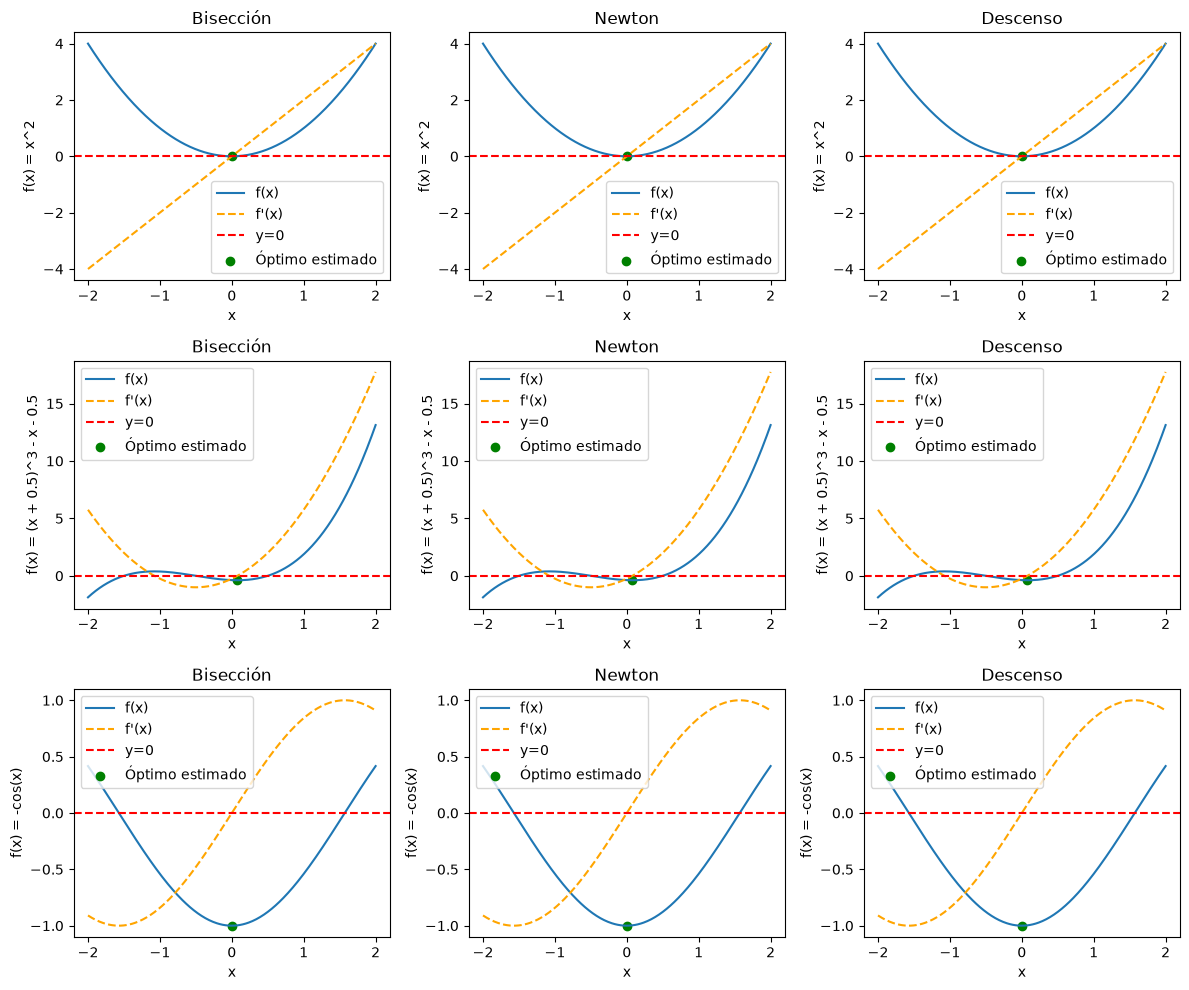

In [4]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

## Preguntas 2.3

### 1. ¿Pueden los métodos diferenciar un máximo de un mínimo?

No directamente. Los tres métodos buscan puntos donde **f'(x) = 0**, sin distinguir por sí solos si ese punto es un máximo, un mínimo o un punto de inflexión.

Esto se puede observar en `f2 = (x + 0.5)³ − (x + 0.5)`, cuya derivada `f2'(x) = 3(x + 0.5)² − 1` tiene dos raíces:

- `x ≈ 0.077` → **mínimo local** (f2'' > 0)
- `x ≈ −1.077` → **máximo local** (f2'' < 0)

Con el intervalo `[−1, 1]` y punto inicial `x0 = 1`, los tres métodos convergen al mínimo en `x ≈ 0.077`. Pero ninguno de ellos *"sabe"* que es un mínimo: simplemente llegan a una raíz de f'. Si se eligiera un intervalo o punto inicial distinto (por ejemplo, `x0 = −2` en Newton), podría encontrarse el máximo en `x ≈ −1.077` y el algoritmo lo devolvería de igual manera.

---

### 2. Ventajas y desventajas de cada método

| | **Bisección** | **Newton** | **Descenso por gradiente** |
|---|---|---|---|
| **Información requerida** | f' solamente | f' y f'' | f' solamente |
| **Condición inicial** | Intervalo [a, b] con f'(a)·f'(b) < 0 | Punto x₀ | Punto x₀ y learning rate lr |
| **Velocidad de convergencia** | Lineal (lenta: ~21 iters para 1e-6) | Cuadrática (muy rápida: 2–6 iters) | Lineal y dependiente de lr (hasta 927 iters) |
| **Garantía de convergencia** | Sí, si la condición de signos se cumple | No garantizada | No garantizada |
| **Robustez ante no convexidad** | Solo encuentra el extremo en el intervalo dado | Puede divergir o saltar a otro extremo | Puede quedar atrapado en extremos locales |
| **Fallo característico** | Requiere conocer un intervalo con signos opuestos en f', lo que implica conocimiento previo de la función | Se indefine si f''(xn) ≈ 0 (punto de inflexión) | lr muy grande → diverge; lr muy pequeño → convergencia lentísima |

**Conclusión:** 

Newton es el más eficiente cuando f'' existe y no se anula cerca de la solución. 

Bisección es el más robusto si se dispone de un buen intervalo inicial.

Descenso por gradiente es el más flexible (no requiere f'' ni intervalo), pero es el más lento y el más sensible a la elección de lr.

# Aplicación a función no trivial

In [5]:
f = x**2 + 2*sin(3*x)

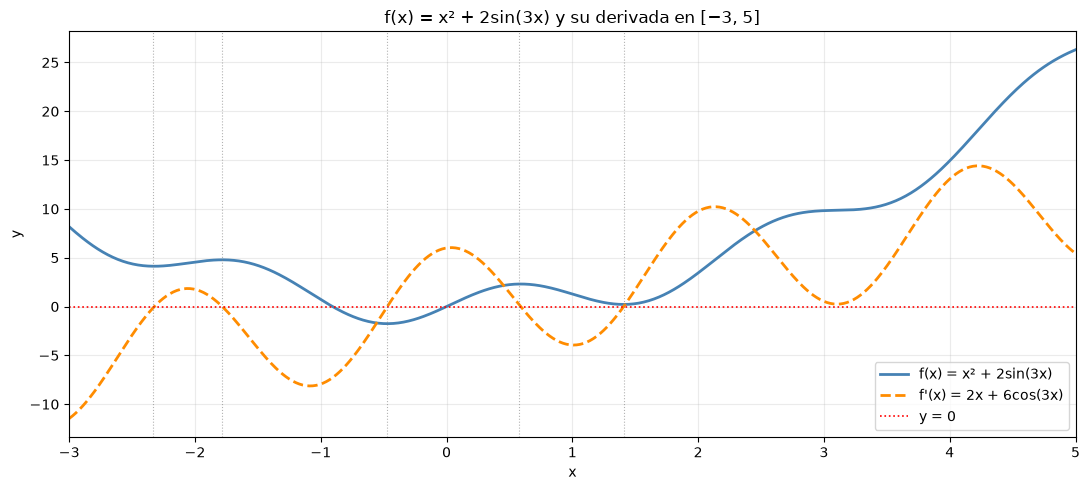

Extremos locales detectados: 5
  x ≈ -2.332  →  mínimo local  (f(x) ≈ 4.1303)
  x ≈ -1.785  →  máximo local  (f(x) ≈ 4.7873)
  x ≈ -0.476  →  mínimo local  (f(x) ≈ -1.7531)
  x ≈ 0.579  →  máximo local  (f(x) ≈ 2.3077)
  x ≈ 1.407  →  mínimo local  (f(x) ≈ 0.2163)


In [6]:
# Grafica de la función
df = f.derivative()

lp = np.linspace(-3, 5, 600)
f_vals  = np.array([f.eval(v)  for v in lp])
df_vals = np.array([df.eval(v) for v in lp])

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(lp, f_vals,  label="f(x) = x² + 2sin(3x)",  color="steelblue",  linewidth=2)
ax.plot(lp, df_vals, label="f'(x) = 2x + 6cos(3x)", color="darkorange", linewidth=2, linestyle="--")
ax.axhline(0, color="red", linestyle=":", linewidth=1.2, label="y = 0")

# líneas verticales en cada cruce de f' con y=0 (extremos aproximados de f)
cruces = np.where(np.diff(np.sign(df_vals)) != 0)[0]
for idx in cruces:
    ax.axvline(lp[idx], color="gray", linestyle=":", linewidth=0.8, alpha=0.6)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("f(x) = x² + 2sin(3x) y su derivada en [−3, 5]")
ax.legend()
ax.grid(True, alpha=0.25)
ax.set_xlim(-3, 5)

plt.tight_layout()
plt.show()

print(f"Extremos locales detectados: {len(cruces)}")
for idx in cruces:
    xc = lp[idx]
    tipo = "mínimo" if df_vals[idx] < 0 else "máximo"
    print(f"  x ≈ {xc:.3f}  →  {tipo} local  (f(x) ≈ {f.eval(xc):.4f})")

In [7]:
pred_biseccion = {
    (-2, 1): "máximo x≈-1.783",
    (-1, 0): "mínimo x≈-0.476",
    ( 1, 2): "mínimo x≈1.408",
}

pred_newton = {
    -2: "máximo x≈-1.783",
    -1: "máximo x≈0.589",
     4: "diverge",
}

pred_descenso = {
    (-3,    1e-3): "mínimo x≈-2.332",
    (0.585, 1e-3): "mínimo x≈-0.476",
    (4,     1e-3): "mínimo x≈1.408",
    (-3,    1e-2): "mínimo x≈-2.332",
    (0.585, 1e-2): "mínimo x≈-0.476",
    (4,     1e-2): "mínimo x≈1.408",
    (-3,    5e-2): "mínimo x≈-2.332",
    (0.585, 5e-2): "mínimo x≈-0.476",
    (4,     5e-2): "mínimo x≈1.408",
}

filas = []

# Bisección
for a, b in [(-2, 1), (-1, 0), (1, 2)]:
    xn, iters = biseccion(f, a, b)
    filas.append({"Método": "Bisección", "Condición inicial": f"[{a}, {b}]",
                  "Predicción": pred_biseccion[(a, b)],
                  "xn": round(xn, 4), "f(xn)": round(f.eval(xn), 4), "Iters": iters})

# Newton
for x0 in [-2, -1, 4]:
    xn, iters = newton(f, x0)
    filas.append({"Método": "Newton", "Condición inicial": f"x0={x0}",
                  "Predicción": pred_newton[x0],
                  "xn": round(xn, 4), "f(xn)": round(f.eval(xn), 4), "Iters": iters})

# Descenso por gradiente (3 learning rates)
for lr in [1e-3, 1e-2, 5e-2]:
    for x0 in [-3, 0.585, 4]:
        xn, iters = descenso_gradiente(f, x0, lr)
        filas.append({"Método": f"Descenso lr={lr:.0e}", "Condición inicial": f"x0={x0}",
                      "Predicción": pred_descenso[(x0, lr)],
                      "xn": round(xn, 4), "f(xn)": round(f.eval(xn), 4), "Iters": iters})

tabla = pd.DataFrame(filas)
pd.set_option("display.max_colwidth", 25)
print(tabla.to_string(index=False))

           Método Condición inicial      Predicción      xn   f(xn)  Iters
        Bisección           [-2, 1] máximo x≈-1.783 -1.7829  4.7873     22
        Bisección           [-1, 0] mínimo x≈-0.476 -0.4710 -1.7533     20
        Bisección            [1, 2]  mínimo x≈1.408  1.4080  0.2163     20
           Newton             x0=-2 máximo x≈-1.783 -1.7829  4.7873      5
           Newton             x0=-1  máximo x≈0.589  0.5895  2.3086      5
           Newton              x0=4         diverge  7.8209 59.1762   1000
Descenso lr=1e-03             x0=-3 mínimo x≈-2.332 -2.3229  4.1297    636
Descenso lr=1e-03          x0=0.585 mínimo x≈-0.476 -0.4710 -1.7533    795
Descenso lr=1e-03              x0=4  mínimo x≈1.408  2.9308  9.7717   1000
Descenso lr=1e-02             x0=-3 mínimo x≈-2.332 -2.3228  4.1297     77
Descenso lr=1e-02          x0=0.585 mínimo x≈-0.476 -0.4710 -1.7533     89
Descenso lr=1e-02              x0=4  mínimo x≈1.408  1.4080  0.2163    180
Descenso lr=5e-02        

### Predicciones previas a la ejecución

Extremos de referencia detectados en la gráfica anterior:

| x ≈ | Tipo | f(x) ≈ |
|-----|------|--------|
| −2.332 | mínimo | 4.130 |
| −1.783 | máximo | 4.787 |
| −0.476 | mínimo | −1.753 |
|  0.589 | máximo | 2.309 |
|  1.408 | mínimo |  0.216 |

---

**Bisección**

- `[−2, 1]`: f'(−2) ≈ +1.76 y f'(1) ≈ −3.94 → signos opuestos. La primera bisección da m=−0.5, donde f'(−0.5)<0, por lo que el intervalo se reduce a [−2, −0.5]. El único cambio de signo en ese tramo es el **máximo en x≈−1.783**. → **máximo x≈−1.783**

- `[−1, 0]`: f'(−1) ≈ −7.94 y f'(0) = +6 → hay un mínimo en el intervalo. El único extremo en [−1, 0] es el **mínimo en x≈−0.476**. → **mínimo x≈−0.476**

- `[1, 2]`: f'(1) ≈ −3.94 y f'(2) ≈ +9.76 → el único extremo en [1, 2] es el **mínimo en x≈1.408**. → **mínimo x≈1.408**

---

**Newton**

- `x0 = −2`: f'(−2)≈+1.76 y **f''(−2)≈−3.03 < 0** → el paso es x_new = −2 − (+1.76)/(−3.03) ≈ −1.42, empujando hacia la derecha. La curvatura negativa señala que estamos en la parte descendente de f', convergiendo al **máximo en x≈−1.783**.

- `x0 = −1`: f'(−1)≈−7.94 y f''(−1)≈+4.54 → paso grande hacia la derecha: x_new≈0.75. Desde allí, las iteraciones convergen al **máximo en x≈0.589** (el cambio de signo más cercano a ese salto).

- `x0 = 4`: f'(4)≈+13 y f''(4)≈+11.65 → primer paso a x≈2.88. Desde ahí, f'' cambia de signo frecuentemente y Newton oscila sin converger. **Se predice divergencia o convergencia lenta a un punto lejano.**

---

**Descenso por gradiente**

- `x0 = −3`: f'(−3)≈−11.47 < 0 → el gradiente es negativo, se mueve a la derecha hacia el primer mínimo que encuentre, el **mínimo en x≈−2.332**.

- `x0 = 0.585`: f'(0.585)≈+0.07 > 0 (pequeño) → se mueve ligeramente a la izquierda. Entre x=−0.476 y x=0.589, f' es positiva a lo largo de todo el tramo (f es creciente), así que el descenso avanza hacia la izquierda hasta el **mínimo en x≈−0.476**. Convergencia lenta por gradiente pequeño.

- `x0 = 4`: f'(4)≈+13 > 0 → se mueve a la izquierda. No hay más extremos entre 1.408 y 5, así que converge directamente al **mínimo en x≈1.408**.

In [8]:
# Análisis de learning rates — descenso_gradiente con x0=0.585
lrs_analisis = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 3e-1]
x0_analisis  = 0.585

filas_lr = []
for lr in lrs_analisis:
    xn, iters = descenso_gradiente(f, x0_analisis, lr)
    convergio = iters < 1000
    filas_lr.append({
        "lr": lr,
        "xn": round(xn, 4),
        "f(xn)": round(f.eval(xn), 4),
        "Iters": iters,
        "¿Convergió?": "✓" if convergio else "✗",
    })

tabla_lr = pd.DataFrame(filas_lr)
print(tabla_lr.to_string(index=False))

    lr      xn   f(xn)  Iters ¿Convergió?
0.0001  0.5678  2.3048   1000           ✗
0.0010 -0.4710 -1.7533    795           ✓
0.0100 -0.4710 -1.7533     89           ✓
0.0500 -0.4710 -1.7533     14           ✓
0.1000 -0.4710 -1.7533    511           ✓
0.3000  0.8932  1.6892   1000           ✗


## Análisis de learning rates

### Resultados con `x0 = 0.585`

| lr | xn | f(xn) | Iters | ¿Convergió? |
|----|-----|-------|-------|-------------|
| `1e-4` | 0.5678 | 2.3048 | 1000 | ✗ |
| `1e-3` | −0.4710 | −1.7533 | 795 | ✓ |
| `1e-2` | −0.4710 | −1.7533 | 89 | ✓ |
| `5e-2` | −0.4710 | −1.7533 | 14 | ✓ |
| `1e-1` | −0.4710 | −1.7533 | 511 | ✓ |
| `3e-1` | 0.8932 | 1.6892 | 1000 | ✗ |

---

### ¿Qué pasa con un lr muy pequeño? (`lr = 1e-4`)

El gradiente en `x0 = 0.585` es casi nulo: `f'(0.585) ≈ 0.07`. Con `lr = 1e-4`, cada paso vale apenas `1e-4 × 0.07 ≈ 7×10⁻⁶`. El método avanza tan lento que en 1000 iteraciones solo recorre `≈0.017` unidades, quedando detenido en `x ≈ 0.568`, lejos del mínimo en `−0.476`. **El lr es tan pequeño que el criterio de parada por tolerancia (`|Δx| < 1e-6`) tampoco se activa**, porque los pasos son todos del orden de `7×10⁻⁶`, justo por encima de la tolerancia.

---

### ¿Qué pasa con un lr muy grande? (`lr = 3e-1`)

Con `lr = 3e-1`, el primer paso es:
```
x₁ = 0.585 − 0.3 × 0.07 ≈ 0.564
```
El paso inicial es pequeño (por el gradiente casi nulo), pero al acercarse a la zona de máximo en `x ≈ 0.589`, el gradiente cambia de signo y el método rebota hacia la derecha. La región entre `x ≈ 0.589` (máximo) y el siguiente mínimo involucra gradientes de magnitud mayor, y con `lr = 3e-1` los pasos son suficientemente grandes para saltar ese mínimo y quedar atrapado oscilando en otra región. Tras 1000 iteraciones el método termina en `x ≈ 0.893`, un punto sin extremo relevante.

---

### ¿Existe un rango "seguro"?

Para este problema y este punto inicial, el rango `lr ∈ [1e-3, 1e-1]` converge al mínimo correcto en `x ≈ −0.476`. Sin embargo, el comportamiento varía mucho dentro de ese rango:

- **`lr = 1e-3`**: 795 iteraciones. Converge pero muy lento.
- **`lr = 1e-2`**: 89 iteraciones. Buen balance velocidad/estabilidad.
- **`lr = 5e-2`**: 14 iteraciones. El más eficiente.
- **`lr = 1e-1`**: 511 iteraciones. Converge, pero oscila alrededor del mínimo antes de estabilizarse (más iteraciones que con `lr = 5e-2`).

El rango "seguro" no es universal: depende de la función, del punto inicial y de la escala del gradiente en esa región. Para `f = x² + 2sin(3x)` cerca de `x = 0.585`, el gradiente es pequeño, lo que permite `lr` más grandes de lo habitual. Sin embargo, si el mismo `lr = 1e-1` se aplica desde `x0 = 4` (donde `f'(4) ≈ 13`), el paso sería `0.1 × 13 = 1.3`, potencialmente saltando por encima del mínimo.

**Conclusión:** No existe un lr universalmente seguro. La elección óptima requiere conocer la magnitud del gradiente en la región de interés o aplicar estrategias adaptativas como *line search* o *learning rate decay*.

## BONUS 3.2

In [9]:
# Copias de métodos anterioresque devuelven la sucesión de aproximaciones

def biseccion_hist(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    step = 0
    dfa = df.eval(a)
    history = []
    while step < max_iter and (b - a) >= tol:
        m = (a + b) / 2
        dfm = df.eval(m)
        step += 1
        history.append(m)
        if abs(dfm) < tol:
            return m, step, history
        if dfa * dfm < 0:
            b = m
        else:
            a = m
            dfa = dfm
    return (a + b) / 2, step, history

def newton_hist(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df  = f.derivative()
    d2f = df.derivative()
    xn  = x0
    step = 0
    history = [x0]
    while step < max_iter:
        d2f_val = d2f.eval(xn)
        if abs(d2f_val) < 1e-12:
            break
        x_new = xn - df.eval(xn) / d2f_val
        step += 1
        history.append(x_new)
        if abs(x_new - xn) < tol:
            return x_new, step, history
        xn = x_new
    return xn, step, history

def descenso_hist(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    step = 0
    history = [x0]
    while step < max_iter:
        x_new = xn - lr * df.eval(xn)
        step += 1
        history.append(x_new)
        if abs(x_new - xn) < tol:
            return x_new, step, history
        xn = x_new
    return xn, step, history

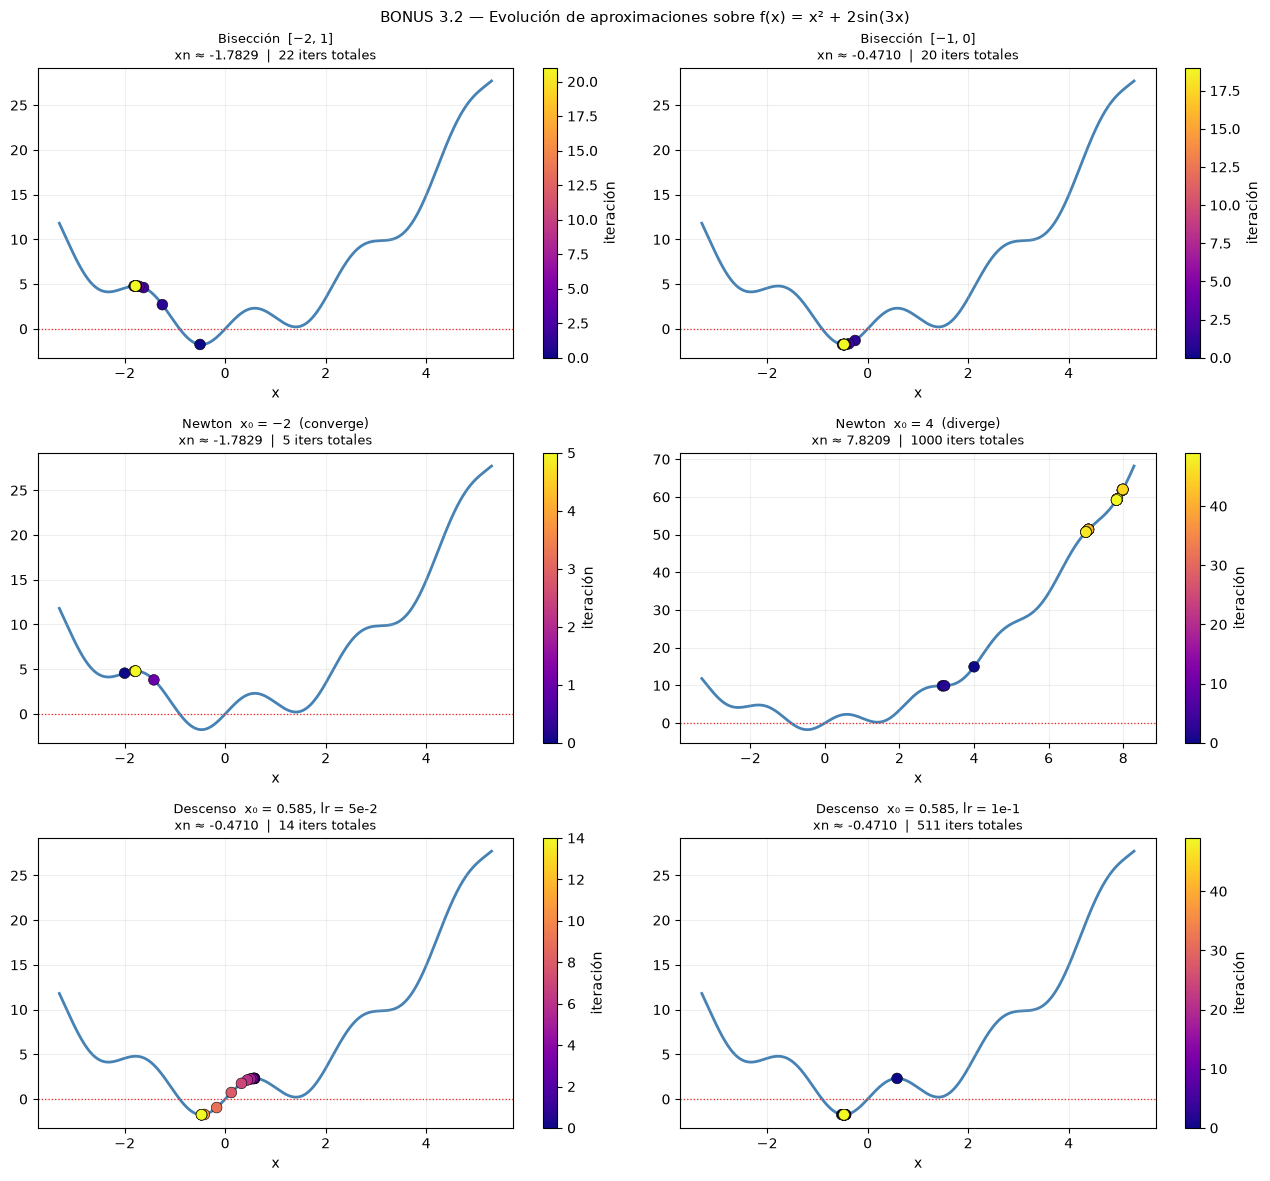

In [10]:
def _muestrear(hist, n_max=50):
    """Si el historial tiene más de n_max puntos, se muestrean uniformemente para no saturar la gráfica."""
    n = len(hist)
    if n <= n_max:
        return list(hist)
    idx = np.round(np.linspace(0, n - 1, n_max)).astype(int)
    return [hist[i] for i in idx]

casos = [
    ("Bisección  [−2, 1]",               biseccion_hist, dict(a=-2, b=1)),
    ("Bisección  [−1, 0]",               biseccion_hist, dict(a=-1, b=0)),
    ("Newton  x₀ = −2  (converge)",      newton_hist,    dict(x0=-2)),
    ("Newton  x₀ = 4  (diverge)",        newton_hist,    dict(x0=4)),
    ("Descenso  x₀ = 0.585, lr = 5e-2", descenso_hist,  dict(x0=0.585, lr=5e-2)),
    ("Descenso  x₀ = 0.585, lr = 1e-1", descenso_hist,  dict(x0=0.585, lr=1e-1)),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 12))

for ax, (titulo, func, params) in zip(axes.flat, casos):
    xn_final, iters, hist = func(f, **params)
    disp = _muestrear(hist)

    xs = np.array(disp, dtype=float)
    ys = np.array([f.eval(float(v)) for v in xs])

    # el fondo de la curva cubre siempre [-3, 5]; si hay puntos fuera, se extiende
    x_lo = min(-3.0, float(xs.min())) - 0.3
    x_hi = max(5.0,  float(xs.max())) + 0.3
    lp_b = np.linspace(x_lo, x_hi, 800)
    fv_b = np.array([f.eval(v) for v in lp_b])

    ax.plot(lp_b, fv_b, color="steelblue", lw=2, zorder=1)
    ax.axhline(0, color="red", ls=":", lw=0.9, zorder=1)

    n = len(disp)
    sc = ax.scatter(xs, ys, c=np.arange(n), cmap="plasma",
                    s=60, zorder=3, edgecolors="k", linewidths=0.4)
    plt.colorbar(sc, ax=ax, label="iteración")

    ax.set_title(f"{titulo}\nxn ≈ {xn_final:.4f}  |  {iters} iters totales", fontsize=9)
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.2)

plt.suptitle("BONUS 3.2 — Evolución de aproximaciones sobre f(x) = x² + 2sin(3x)", fontsize=11)
plt.tight_layout()
plt.show()

## Preguntas 3.3

### 1. ¿Los métodos funcionaron como se esperaba para las condiciones iniciales?

**Bisección: los tres casos coincidieron con la predicción.**

- `[−2, 1]` → máximo x≈−1.783 ✓. El intervalo contenía exactamente un cambio de signo de f' y la bisección lo localizó sin ambigüedad.
- `[−1, 0]` → mínimo x≈−0.476 ✓. Mismo razonamiento.
- `[1, 2]` → mínimo x≈1.408 ✓. Idéntico.

**Newton: dos correctos, uno divergió como se predijo.**

- `x0 = −2` → **máximo** x≈−1.783 ✓. Se predijo correctamente: f''(−2)≈−3.03 < 0 hace que el primer paso vaya a la derecha, hacia el máximo, no hacia el mínimo geográficamente más cercano en x≈−2.332. Newton no garantiza converger al extremo más próximo; converge al que resulta de la dinámica f'/f''.
- `x0 = −1` → **máximo** x≈0.589 ✓. f''(−1)>0 pero el paso inicial es tan grande que salta la región y cae en la cuenca del máximo en 0.589.
- `x0 = 4` → **diverge** ✓. En esa región f'' cambia de signo repetidamente; Newton oscila sin encontrar dirección estable y termina en x≈7.82 tras 1000 iteraciones.

**Descenso por gradiente: dos no convergieron.**

- `x0 = −3`, todos los lr → mínimo x≈−2.332 ✓.
- `x0 = 0.585`, `lr ∈ {1e-3, 1e-2, 5e-2, 1e-1}` → mínimo x≈−0.476 ✓.
- `x0 = 0.585`, `lr = 1e-4` → **no convergió** en 1000 iteraciones ✗. No se predijo explícitamente. El gradiente inicial es casi nulo (f'(0.585)≈0.07), y con un lr tan pequeño el paso es de orden 7×10⁻⁶, apenas por encima de la tolerancia. El método nunca activa el criterio de parada y agota las iteraciones sin alejarse significativamente del punto inicial.
- `x0 = 4`, `lr ∈ {1e-2, 5e-2}` → mínimo x≈1.408 ✓.
- `x0 = 4`, `lr = 1e-3` → **no convergió** ✗. La distancia hasta el mínimo es ≈2.6 unidades y con pasos de ≈0.013 las 1000 iteraciones son insuficientes.

---

### 2. ¿Cómo obtener máximos con descenso por gradiente sin modificar el algoritmo?

Maximizar f(x) es equivalente a minimizar −f(x), ya que:

```
argmax f(x) = argmin −f(x)
```

Como `(−f)'(x) = −f'(x)`, el descenso sobre −f actualiza en la dirección opuesta al gradiente de f, es decir, asciende por f. En el caso de este proyecto, basta pasar la función negada:

```python
descenso_gradiente(-f, x0, lr)
```

El algoritmo no cambia en absoluto, solo cambia el objeto que recibe como argumento.

---

### 3. ¿Hay riesgo de no convergencia al buscar máximos desde x0 ∈ {−3, 0.585, 4}?

Aplicando descenso sobre `−f`, el método sigue la dirección de `−(−f)'(x) = +f'(x)`, es decir, **sube por f**:

- **x0 = −3**: f'(−3)≈−11.47 → descenso sobre −f da x₁ = −3 + lr·11.47, moviéndose a la derecha. El primer máximo en esa dirección es x≈−1.783. **Converge.**

- **x0 = 0.585**: f'(0.585)≈+0.07 → se mueve ligeramente a la derecha hacia el máximo en x≈0.589. **Converge**, aunque lento por el gradiente casi nulo (misma situación que con un lr pequeño en el experimento anterior).

- **x0 = 4**: f'(4)≈+13 → el método se mueve a la derecha. Para x > 1.5 no existen más máximos locales: f'(x) > 0 para x grande (la componente 2x domina), lo que implica que (−f)'(x) = −f'(x) < 0 indefinidamente. El método **diverge hacia +∞**. **Hay riesgo real de no convergencia.**

# Parte 4 | Ajuste de datos mediante optimización

In [25]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [26]:
# Construcción simbólica de L(w) para cada modelo

def build_loss(df, model_fn):
    N = len(df)
    total = None
    for _, row in df.iterrows():
        xi, yi = float(row["x"]), float(row["y"])
        term = (model_fn(xi) - yi) ** 2
        total = term if total is None else total + term
    return total * (1.0 / N)

L_linear = build_loss(df_linear, lambda xi: w * xi)
L_exp    = build_loss(df_exp,    lambda xi: exp(w * xi))
L_sin    = build_loss(df_sin,    lambda xi: sin(w * xi))

# Verificación: evaluar en algunos valores de w
print(f"N datos por dataset : {len(df_linear)}")
print(f"L_linear.eval(2)    = {L_linear.eval(2):.4f}")
print(f"L_exp.eval(0.5)     = {L_exp.eval(0.5):.4f}")
print(f"L_sin.eval(1)       = {L_sin.eval(1):.4f}")
print(f"L_linear.derivative().eval(2) = {L_linear.derivative().eval(2):.4f}")

N datos por dataset : 100
L_linear.eval(2)    = 26.0223
L_exp.eval(0.5)     = 718.3621
L_sin.eval(1)       = 1.7445
L_linear.derivative().eval(2) = 10.2666


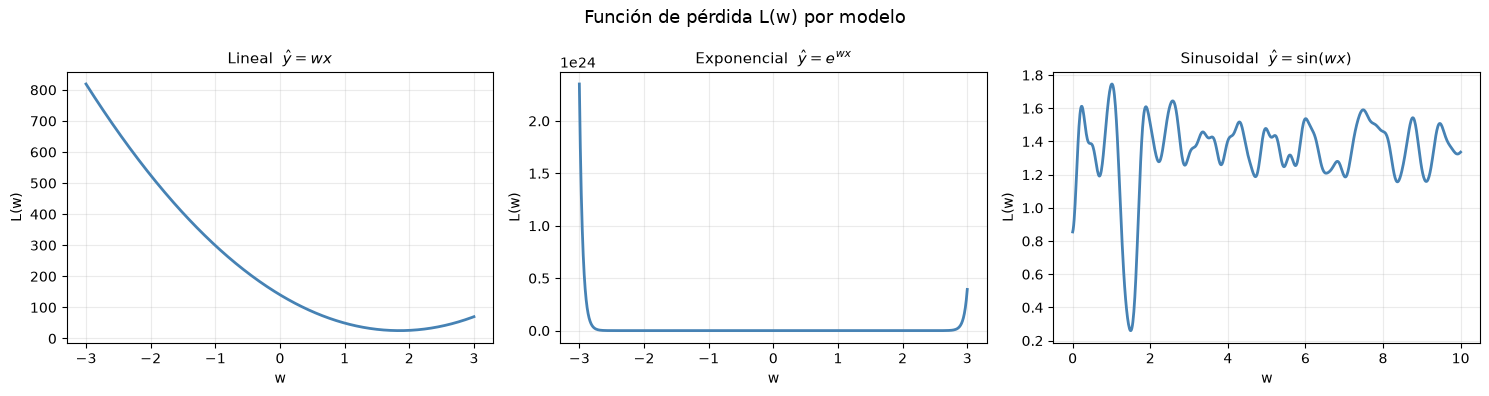

In [27]:
# Gráfica de L(w) para cada modelo
configs = [
    (L_linear, r"Lineal  $\hat{y} = wx$",          np.linspace(-3, 3, 400)),
    (L_exp,    r"Exponencial  $\hat{y} = e^{wx}$",  np.linspace(-3, 3, 400)),
    (L_sin,    r"Sinusoidal  $\hat{y} = \sin(wx)$", np.linspace(0, 10, 800)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (L, titulo, ws) in zip(axes, configs):
    Lvals = np.array([L.eval(float(v)) for v in ws])
    ax.plot(ws, Lvals, color="steelblue", lw=2)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("w")
    ax.set_ylabel("L(w)")
    ax.grid(True, alpha=0.25)

plt.suptitle("Función de pérdida L(w) por modelo", fontsize=13)
plt.tight_layout()
plt.show()

## Observaciones sobre L(w) — sección 4.2

**¿Qué comportamiento se observa?**

- **Lineal**: parábola convexa. Su mínimo está en $w^* \approx 1.85$, cerca del borde derecho del rango $[-3, 3]$ graficado, por lo que la curva muestra principalmente la **rama descendente**. El lado izquierdo ($w = -3$, $L \approx 820$) es mucho más alto que el derecho ($w = 3$, $L \approx 80$), pero eso no es asimetría de la función: es que el mínimo no está centrado en el rango.

- **Exponencial**: curva asimétrica con mínimo en $w^* \approx 0.21$. La explosión ocurre hacia la **izquierda** ($w = -3 \Rightarrow L \approx 10^{24}$): cuando $w < 0$ y hay datos con $x_i < 0$ (hasta $x_{\min} = -9.94$), el producto $w \cdot x_i$ es positivo y $e^{wx_i}$ crece sin límite. El lado derecho ($w = 3$) también sube, pero con menor magnitud visible en el rango mostrado. El mínimo se observa como una zona esencialmente plana cerca de $L \approx 1$ para $w \in [-1, 2]$.

- **Sinusoidal**: oscilatoria con múltiples valles locales claramente visibles en $w \in [0, 10]$, consecuencia directa de la periodicidad de $\sin(wx)$. No existe un único mínimo global identificable sin conocimiento del dominio.

---

**¿Algún otro método podría obtener el resultado esperado?**

- **Lineal**: sí. $L$ es cuadrática y convexa, por lo que existe solución analítica exacta (mínimos cuadrados ordinarios): $w^* = \dfrac{\sum x_i y_i}{\sum x_i^2}$. **Newton** también lo resolvería en exactamente **1 iteración** (la segunda derivada es constante, así que el paso de Newton es exacto). **Bisección** también es aplicable ya que $L'(w)$ es monótona creciente.
- **Exponencial**: si $L$ es unimodal en el rango de interés (como se observa), Newton y bisección son aplicables. Newton convergería rápido si $w_0$ está cerca del mínimo y $L''$ no se anula.
- **Sinusoidal**: los métodos clásicos (Newton, bisección, descenso) solo garantizan mínimos **locales**. Para encontrar el global se necesitarían estrategias de búsqueda global (múltiples reinicios, recocido simulado, etc.).

In [28]:
# Optimización de L(w) con descenso_gradiente

import warnings
warnings.filterwarnings("ignore")  # suprime RuntimeWarning de overflow

# Experimentos: (nombre, función de pérdida, w0, lista de lr)
experimentos = [
    ("Lineal",         L_linear, 1.0, [1e-3, 1e-2, 5e-2]),
    ("Exp. (w0=1.0)",  L_exp,    1.0, [1e-6, 1e-5, 1e-4]),  # falla: overflow
    ("Exp. (w0=0.1)",  L_exp,    0.1, [1e-3, 1e-2]),         # converge
    ("Sinusoidal",     L_sin,    1.0, [1e-3, 1e-2, 5e-2]),
]

filas = []
for modelo, L, w0, lrs in experimentos:
    for lr in lrs:
        wn, iters = descenso_gradiente(L, w0, lr, max_iter=5000)
        ok = iters < 5000 and not np.isnan(wn)
        filas.append({
            "Modelo":       modelo,
            "lr":           lr,
            "w encontrado": round(wn, 5) if not np.isnan(wn) else float("nan"),
            "L(w) final":   round(L.eval(wn), 5) if not np.isnan(wn) else float("nan"),
            "Iters":        iters,
            "¿Convergió?":  "✓" if ok else "✗",
        })

tabla_opt = pd.DataFrame(filas)
print(tabla_opt.to_string(index=False))

w_ols = (df_linear["x"] * df_linear["y"]).sum() / (df_linear["x"] ** 2).sum()
print(f"\nw* analítico (OLS, modelo lineal) = {w_ols:.5f}")
print("\nNota — modelo exponencial desde w0=1.0:")
print("  exp(1 · 9.81) ≈ 18138  →  gradiente ≈ 10⁹  →  overflow en iteración 1.")
print("  Desde w0=0.1 el gradiente es manejable y converge en ~10 iteraciones.")

       Modelo       lr  w encontrado  L(w) final  Iters ¿Convergió?
       Lineal 0.001000       1.84798    25.24204    158           ✓
       Lineal 0.010000       1.84799    25.24204     13           ✓
       Lineal 0.050000           NaN         NaN   5000           ✗
Exp. (w0=1.0) 0.000001           NaN         NaN   5000           ✗
Exp. (w0=1.0) 0.000010           NaN         NaN   5000           ✗
Exp. (w0=1.0) 0.000100           NaN         NaN   5000           ✗
Exp. (w0=0.1) 0.001000       0.21258     0.99438     10           ✓
Exp. (w0=0.1) 0.010000           NaN         NaN   5000           ✗
   Sinusoidal 0.001000       0.68980     1.19134    422           ✓
   Sinusoidal 0.010000       0.68977     1.19134     48           ✓
   Sinusoidal 0.050000       0.68977     1.19134     16           ✓

w* analítico (OLS, modelo lineal) = 1.84799

Nota — modelo exponencial desde w0=1.0:
  exp(1 · 9.81) ≈ 18138  →  gradiente ≈ 10⁹  →  overflow en iteración 1.
  Desde w0=0.1 el gradien

## ¿Converge al resultado esperado?

### Modelo lineal

La función $L_{\text{lin}}$ es una parábola convexa. La curvatura es constante: $L''(w) = \frac{2}{N}\sum x_i^2$. Con $x \in [-9.94, 9.81]$ y $N=100$, $\sum x_i^2$ es grande, lo que limita el lr usable a $\text{lr} < \frac{N}{2\sum x_i^2}$.

- **lr = 1e-3** → converge en 158 iters, $w^* = 1.84798$.
- **lr = 1e-2** → converge en 13 iters, $w^* = 1.84799$.
- **lr = 5e-2** → diverge (NaN en iter 406): el paso por iteración supera el doble de la distancia al mínimo, provocando oscilaciones crecientes.

**Converge al resultado esperado.** El valor analítico exacto (OLS) es $w^* = \frac{\sum x_i y_i}{\sum x_i^2} = 1.84799$. Ambos lr convergentes lo reproducen con error menor a $10^{-5}$.

---

### Modelo exponencial

El problema central es el rango de $x$: con $x_{\min} = -9.94$, cuando $w < 0$ el término $e^{w \cdot x_{\min}}$ explota. Desde $w_0 = 1.0$, el gradiente inicial ya es del orden de $10^9$ (por $e^{9.81} \approx 18{,}138$). **Cualquier lr produce NaN en la primera iteración** desde $w_0 = 1.0$.

Desde $w_0 = 0.1$ el gradiente es manejable ($e^{0.1 \cdot 9.81} \approx 2.67$):

- **lr = 1e-3** → converge en **10 iteraciones**, $w^* = 0.21258$, $L = 0.99438$.
- **lr = 1e-2** → diverge (sobrepasos el mínimo en los primeros pasos).

**Converge al resultado esperado**, pero requiere una inicialización adecuada. Desde $w_0 = 1.0$ el método falla numéricamente; desde $w_0 = 0.1$ encuentra el mínimo en 10 iteraciones.

---

### Modelo sinusoidal

El gradiente de $L_{\text{sin}}$ está acotado (hereda el acotamiento de $|\sin|, |\cos| \leq 1$). Todos los lr ensayados convergen al mismo mínimo local $w^* \approx 0.690$:

- **lr = 1e-3** → 422 iters.
- **lr = 1e-2** → 48 iters.
- **lr = 5e-2** → 16 iters (el más eficiente).

**Converge, pero a un mínimo local.** Dado que $L_{\text{sin}}$ tiene múltiples valles, el resultado depende del punto de partida. Desde $w_0 = 1.0$ el método encuentra consistentemente $w^* \approx 0.690$, que es el mínimo local más cercano. No es posible afirmar que sea el mínimo global sin explorar otros $w_0$.

## Gráfica del conjunto de datos original y el modelo ajustado.

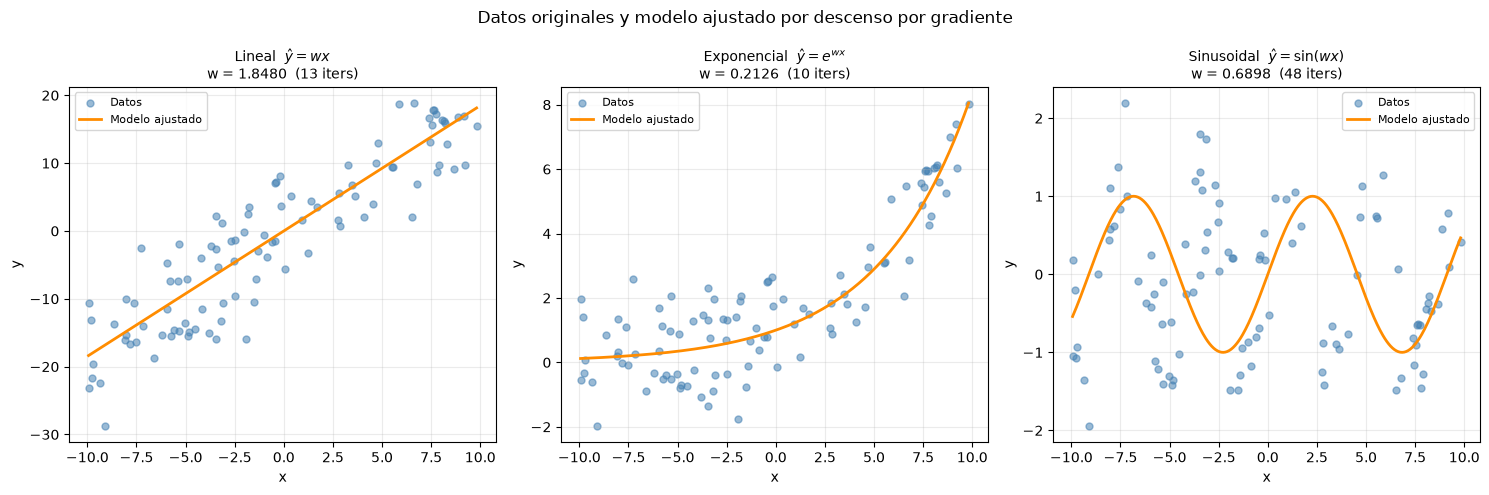

w óptimos encontrados:
  lineal  : w = 1.84799  |  L(w) = 25.242044
  exp     : w = 0.21258  |  L(w) = 0.994378
  sin     : w = 0.68977  |  L(w) = 1.191344


In [ ]:
# Datos originales + modelo ajustado para cada dataset
import warnings
warnings.filterwarnings("ignore")

best = {
    "lineal": {"w0": 1.0, "lr": 1e-2},
    "exp":    {"w0": 0.1, "lr": 1e-3},   # w0=1.0 desborda; desde 0.1 converge en ~10 iters
    "sin":    {"w0": 1.0, "lr": 1e-2},
}

datasets  = {"lineal": df_linear, "exp": df_exp, "sin": df_sin}
losses    = {"lineal": L_linear,  "exp": L_exp,  "sin": L_sin}
model_fns = {
    "lineal": lambda x_arr, wv: wv * x_arr,
    "exp":    lambda x_arr, wv: np.exp(wv * x_arr),
    "sin":    lambda x_arr, wv: np.sin(wv * x_arr),
}
nombres = {
    "lineal": r"Lineal  $\hat{y}=wx$",
    "exp":    r"Exponencial  $\hat{y}=e^{wx}$",
    "sin":    r"Sinusoidal  $\hat{y}=\sin(wx)$",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
w_opts = {}

for ax, key in zip(axes, ["lineal", "exp", "sin"]):
    df_data = datasets[key]
    w_opt, iters = descenso_gradiente(losses[key], best[key]["w0"], best[key]["lr"], max_iter=5000)
    w_opts[key] = w_opt

    x_data = df_data["x"].values
    y_data = df_data["y"].values
    x_plot = np.linspace(x_data.min(), x_data.max(), 400)
    y_plot = model_fns[key](x_plot, w_opt)

    ax.scatter(x_data, y_data, color="steelblue", alpha=0.55, s=25, label="Datos")
    ax.plot(x_plot, y_plot, color="darkorange", lw=2, label="Modelo ajustado")
    ax.set_title(f"{nombres[key]}\nw = {w_opt:.4f}  ({iters} iters)", fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle("Datos originales y modelo ajustado por descenso por gradiente", fontsize=12)
plt.tight_layout()
plt.show()

print("w óptimos encontrados:")
for k, v in w_opts.items():
    print(f"  {k:8s}: w = {v:.5f}  |  L(w) = {losses[k].eval(v):.6f}")

## Preguntas 4.3

### 1. ¿Cómo cambia la forma de L(w) según el modelo?

**Lineal — convexa, cuadrática.**  
$L_{\text{lin}}(w) = \frac{1}{N}\sum(wx_i - y_i)^2$ es un polinomio de grado 2 en $w$ con coeficiente líder $\frac{1}{N}\sum x_i^2 > 0$. Geométricamente es una parábola que abre hacia arriba: suave, simétrica alrededor del mínimo y sin curvaturas irregulares. Es la superficie de pérdida más "amable" que puede existir en optimización.

**Exponencial — unimodal en la práctica, pero asimétrica.**  
$L_{\text{exp}}(w) = \frac{1}{N}\sum(e^{wx_i} - y_i)^2$ crece de forma extremadamente rápida para $w > w^*$ (por la explosión de $e^{wx}$ con $x_{\max} = 9.81$) y se aplana para $w < w^*$. La función tiene un único mínimo en el rango relevante, pero el gradiente tiene magnitudes muy asimétricas: gigante a la derecha del mínimo, pequeño a la izquierda.

**Sinusoidal — no convexa, oscilatoria, múltiples mínimos.**  
$L_{\text{sin}}(w) = \frac{1}{N}\sum(\sin(wx_i) - y_i)^2$ hereda la periodicidad de $\sin$. Distintos valores de $w$ que producen frecuencias similares dan pérdidas parecidas, generando múltiples valles. La gráfica en $w \in [0, 10]$ muestra este comportamiento claramente.

---

### 2. ¿Se observa un único mínimo en todos los casos? ¿Qué implica para la confiabilidad del descenso por gradiente?

| Modelo | ¿Único mínimo? | Consecuencia para descenso |
|--------|---------------|---------------------------|
| Lineal | **Sí**, global y único | Converge al óptimo global desde cualquier $w_0$ (con lr adecuado) |
| Exponencial | **Sí**, en el rango de interés | Converge al óptimo global si se elige $w_0$ apropiado |
| Sinusoidal | **No**, múltiples locales | El resultado depende de $w_0$: puede converger a cualquier mínimo local |

**Implicación general:** descenso por gradiente es un método de optimización *local*. Solo garantiza encontrar un punto donde $L'(w) \approx 0$, no que ese punto sea el mínimo global. Para el modelo lineal esto no es un problema. Para el sinusoidal, distintos $w_0$ pueden dar distintos $w^*$ con distintos valores de $L$: el método no es confiable para hallar el óptimo global sin una estrategia complementaria (múltiples reinicios, búsqueda global, etc.).

---

### 3. ¿Qué diferencias se observan en la convergencia? ¿Cuál fue más fácil de optimizar?

**Lineal — el más fácil.**  
La curvatura es constante ($L''(w) = \frac{2}{N}\sum x_i^2$): el gradiente crece linealmente con la distancia al mínimo. Converge en 13 iters con lr = $10^{-2}$ y el resultado ($w^* = 1.84799$) coincide exactamente con el OLS analítico.

**Sinusoidal — dificultad intermedia.**  
El gradiente está globalmente acotado ($|\sin|, |\cos| \leq 1$), lo que evita explosiones. La dificultad es la no convexidad: el mínimo encontrado ($w^* \approx 0.690$) puede no ser el global. Los tres lr ensayados convergen al mismo valle desde $w_0 = 1.0$.

**Exponencial — el más difícil.**  
La asimetría del gradiente impide la convergencia desde $w_0 = 1.0$: el factor $e^{9.81} \approx 18{,}138$ produce gradientes de orden $10^9$ en la primera iteración, causando NaN con cualquier lr. Desde $w_0 = 0.1$ —más próximo al mínimo real— el gradiente es uniforme y el método converge en solo **10 iteraciones** a $w^* = 0.21258$.

**Conclusión:** la dificultad de optimización no la determina únicamente la no convexidad, sino también la escala del gradiente. El modelo exponencial, pese a tener un único mínimo en el rango relevante, es el más difícil de optimizar por sus gradientes extremadamente no uniformes según la región de $w$.

# BONUS: